In [46]:
# ============================================================
# УСТАНОВКА БИБЛИОТЕК
# Запустите эту ячейку первой; остальные зависят от неё.
# ============================================================
!pip install shap --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, gc, warnings

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay,
    precision_score, recall_score
)
import shap

# Фиксируем зерно для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')

print("Все библиотеки загружены")
print(f"  pandas {pd.__version__} | numpy {np.__version__} | shap {shap.__version__}")

Все библиотеки загружены
  pandas 2.3.3 | numpy 2.4.6 | shap 0.51.0


In [47]:
# ============================================================
# 1. ЗАГРУЗКА ДАННЫХ
# ============================================================

# Определяем среду и путь к данным
# Если запускаете в Kaggle — путь определится автоматически
# Если в Colab — укажите свой путь к папке с файлами вручную

if os.path.isdir('/kaggle/input/mastercard-mdq'):
    # Kaggle — путь определился автоматически
    DATA_PATH = '/kaggle/input/mastercard-mdq/'
elif os.path.isdir('/kaggle/input/datasets/adilbek97/mastercard'):
    DATA_PATH = '/kaggle/input/datasets/adilbek97/mastercard/'
else:
    # Colab — маунтируем Drive и указываем путь вручную
    from google.colab import drive
    drive.mount('/content/drive/')
    DATA_PATH = '/content/drive/MyDrive/MDQ/'  # <-- поменяйте если папка называется иначе

print(f"Загружаем данные из: {DATA_PATH}")

merchants_df = pd.read_parquet(DATA_PATH + 'merchants_reference.parquet')
business_df  = pd.read_parquet(DATA_PATH + 'business_cards_MDQ.parquet')
consumer_df  = pd.read_parquet(DATA_PATH + 'consumer_cards_MDQ.parquet')

# Целевая переменная: 1 = бизнес-карта, 0 = потребительская карта
business_df['target'] = 1
consumer_df['target'] = 0

print(f"Business transactions : {len(business_df):>10,}  |  unique cards: {business_df['card_number'].nunique():,}")
print(f"Consumer transactions : {len(consumer_df):>10,}  |  unique cards: {consumer_df['card_number'].nunique():,}")

all_transactions = pd.concat([business_df, consumer_df], ignore_index=True)
del business_df, consumer_df
gc.collect()

# Обогащение справочником мерчантов
df = all_transactions.merge(merchants_df, on='merchant_id', how='left', suffixes=('', '_merch'))
del all_transactions, merchants_df
gc.collect()

# Переименуем mcc после мержа, чтобы не было путаницы
df.rename(columns={'mcc': 'mcc_tx', 'mcc_merch': 'mcc_ref'}, errors='ignore', inplace=True)

print(f"\nИтоговый датасет: {df.shape[0]:,} строк × {df.shape[1]} колонок")
print(f"Период: {df['transaction_date'].min()} — {df['transaction_date'].max()}")

Загружаем данные из: /kaggle/input/datasets/adilbek97/mastercard/
Business transactions :  2,997,593  |  unique cards: 25,000
Consumer transactions :  9,832,487  |  unique cards: 80,000

Итоговый датасет: 12,830,080 строк × 17 колонок
Период: 2025-10-01 — 2026-03-31


In [48]:
# ============================================================
# 2. ОБРАБОТКА ДАННЫХ
# ============================================================

# --- 2.1 Пропущенные значения ---
null_summary = df.isnull().sum()
null_summary = null_summary[null_summary > 0]
print("Пропуски по колонкам:")
print(null_summary.to_string())

df['merchant_name']    = df['merchant_name'].fillna('Unknown')
df['merchant_country'] = df['merchant_country'].fillna('Unknown')
df['recurring_capable'] = df['recurring_capable'].fillna(False)
df['is_recurring']     = df['is_recurring'].fillna(False)

# --- 2.2 Аномалии в сумме транзакции ---
# Используем 99-й перцентиль для отсечения выбросов
q99 = df['transaction_amount_kzt'].quantile(0.99)
q01 = df['transaction_amount_kzt'].quantile(0.01)
before = len(df)
df = df[(df['transaction_amount_kzt'] >= q01) & (df['transaction_amount_kzt'] <= q99)]
print(f"\nУдалено строк как выбросы по сумме: {before - len(df):,}  ({(before-len(df))/before*100:.2f}%)")

# --- 2.3 Временные признаки (понадобятся в Feature Engineering) ---
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['hour']   = pd.to_datetime(df['transaction_timestamp']).dt.hour
df['weekday'] = df['transaction_date'].dt.dayofweek   # 0=Пн, 6=Вс

print("\nОбработка данных завершена")

Пропуски по колонкам:
Series([], )

Удалено строк как выбросы по сумме: 256,533  (2.00%)

Обработка данных завершена


## 🧠 Обоснование выбора признаков (Feature Engineering)

Все признаки агрегируются до уровня **уникальной карты** (card_number).  
Каждый признак отвечает на конкретную бизнес-гипотезу:

| # | Признак | Гипотеза |
|---|---------|----------|
| 1 | `tx_count` | Предприниматели совершают больше транзакций — выше оборот операций |
| 2 | `tx_sum` | Суммарный оборот у бизнеса выше, чем у физлица |
| 3 | `tx_mean` | Средний чек у бизнеса крупнее (оптовые закупки) |
| 4 | `tx_std` | Высокая дисперсия сумм = разнородные деловые расходы |
| 5 | `unique_merchants` | Регулярный пул поставщиков vs хаотичные бытовые траты |
| 6 | `unique_mcc` | Бизнес-карта сфокусирована на узком наборе MCC-категорий |
| 7 | `recurring_ratio` | Ключевой B2B-маркер: подписки на облака, рекламу, логистику |
| 8 | `offline_ratio` | Торговый эквайринг = преимущественно оффлайн-транзакции |
| 9 | `intl_ratio` | Доля зарубежных транзакций — импортёры и онлайн-торговля |
| 10 | `unique_countries` | Широкая география закупок указывает на внешнеэкономическую деятельность |
| 11 | `business_hour_ratio` | Транзакции в рабочее время (8–19ч) — сигнал деловой активности |
| 12 | `weekend_ratio` | Низкая доля покупок в выходные = бизнес-профиль, а не бытовой |
| 13 | `active_days` | Число уникальных дней с транзакциями — регулярность активности |
| 14 | `mcc_hhi` | Индекс Херфиндаля по MCC: высокий HHI = концентрация на бизнес-категориях |

In [49]:
# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================

# Вычисляем булевы флаги прямо в df — без создания копий
df['is_offline']  = (df['channel'] == 'offline').astype('int8')
df['is_intl']     = (df['country'] != 'KZ').astype('int8')
df['is_biz_hour'] = ((df['hour'] >= 8) & (df['hour'] < 19)).astype('int8')
df['is_weekend']  = (df['weekday'] >= 5).astype('int8')

# Один проход groupby — все агрегаты сразу
features_df = df.groupby('card_number').agg(
    tx_count            = ('transaction_amount_kzt', 'count'),
    tx_sum              = ('transaction_amount_kzt', 'sum'),
    tx_mean             = ('transaction_amount_kzt', 'mean'),
    tx_std              = ('transaction_amount_kzt', 'std'),
    unique_merchants    = ('merchant_id', 'nunique'),
    unique_mcc          = ('mcc_tx', 'nunique'),
    recurring_ratio     = ('is_recurring', 'mean'),
    unique_countries    = ('country', 'nunique'),
    active_days         = ('transaction_date', 'nunique'),
    offline_ratio       = ('is_offline', 'mean'),
    intl_ratio          = ('is_intl', 'mean'),
    business_hour_ratio = ('is_biz_hour', 'mean'),
    weekend_ratio       = ('is_weekend', 'mean'),
    target              = ('target', 'max'),
).reset_index()

# Индекс Херфиндаля по MCC — отдельный проход (нужно распределение по категориям)
# Высокий HHI → карта сосредоточена в 1-2 MCC-категориях (характерно для бизнеса)
print("Вычисление индекса HHI...")
mcc_counts = df.groupby(['card_number', 'mcc_tx']).size().reset_index(name='n')
mcc_totals = mcc_counts.groupby('card_number')['n'].transform('sum')
mcc_counts['share'] = mcc_counts['n'] / mcc_totals
mcc_hhi = (mcc_counts.groupby('card_number')['share']
           .apply(lambda x: float((x**2).sum()))  # float() — избегаем FutureWarning в pandas 2.x
           .rename('mcc_hhi')
           .reset_index())
del mcc_counts, mcc_totals
gc.collect()

features_df = features_df.merge(mcc_hhi, on='card_number', how='left')
del mcc_hhi

# Заполняем NaN: у карт с 1 транзакцией std = NaN
features_df['tx_std'] = features_df['tx_std'].fillna(0)

# Освобождаем таблицу транзакций — она больше не нужна
del df
gc.collect()

print(f"Размер таблицы признаков: {features_df.shape}")
print(f"\nРаспределение классов:")
print(features_df['target'].value_counts().rename({0: 'Consumer', 1: 'Business'}))
print(f"\nДоля бизнес-карт: {features_df['target'].mean()*100:.1f}%")
nulls = features_df.isnull().sum()
nulls = nulls[nulls > 0]
print(f"\nПропуски:\n{nulls}" if len(nulls) else "\nПропусков нет")

Вычисление индекса HHI...
Размер таблицы признаков: (105000, 16)

Распределение классов:
target
Consumer    80000
Business    25000
Name: count, dtype: int64

Доля бизнес-карт: 23.8%

Пропусков нет


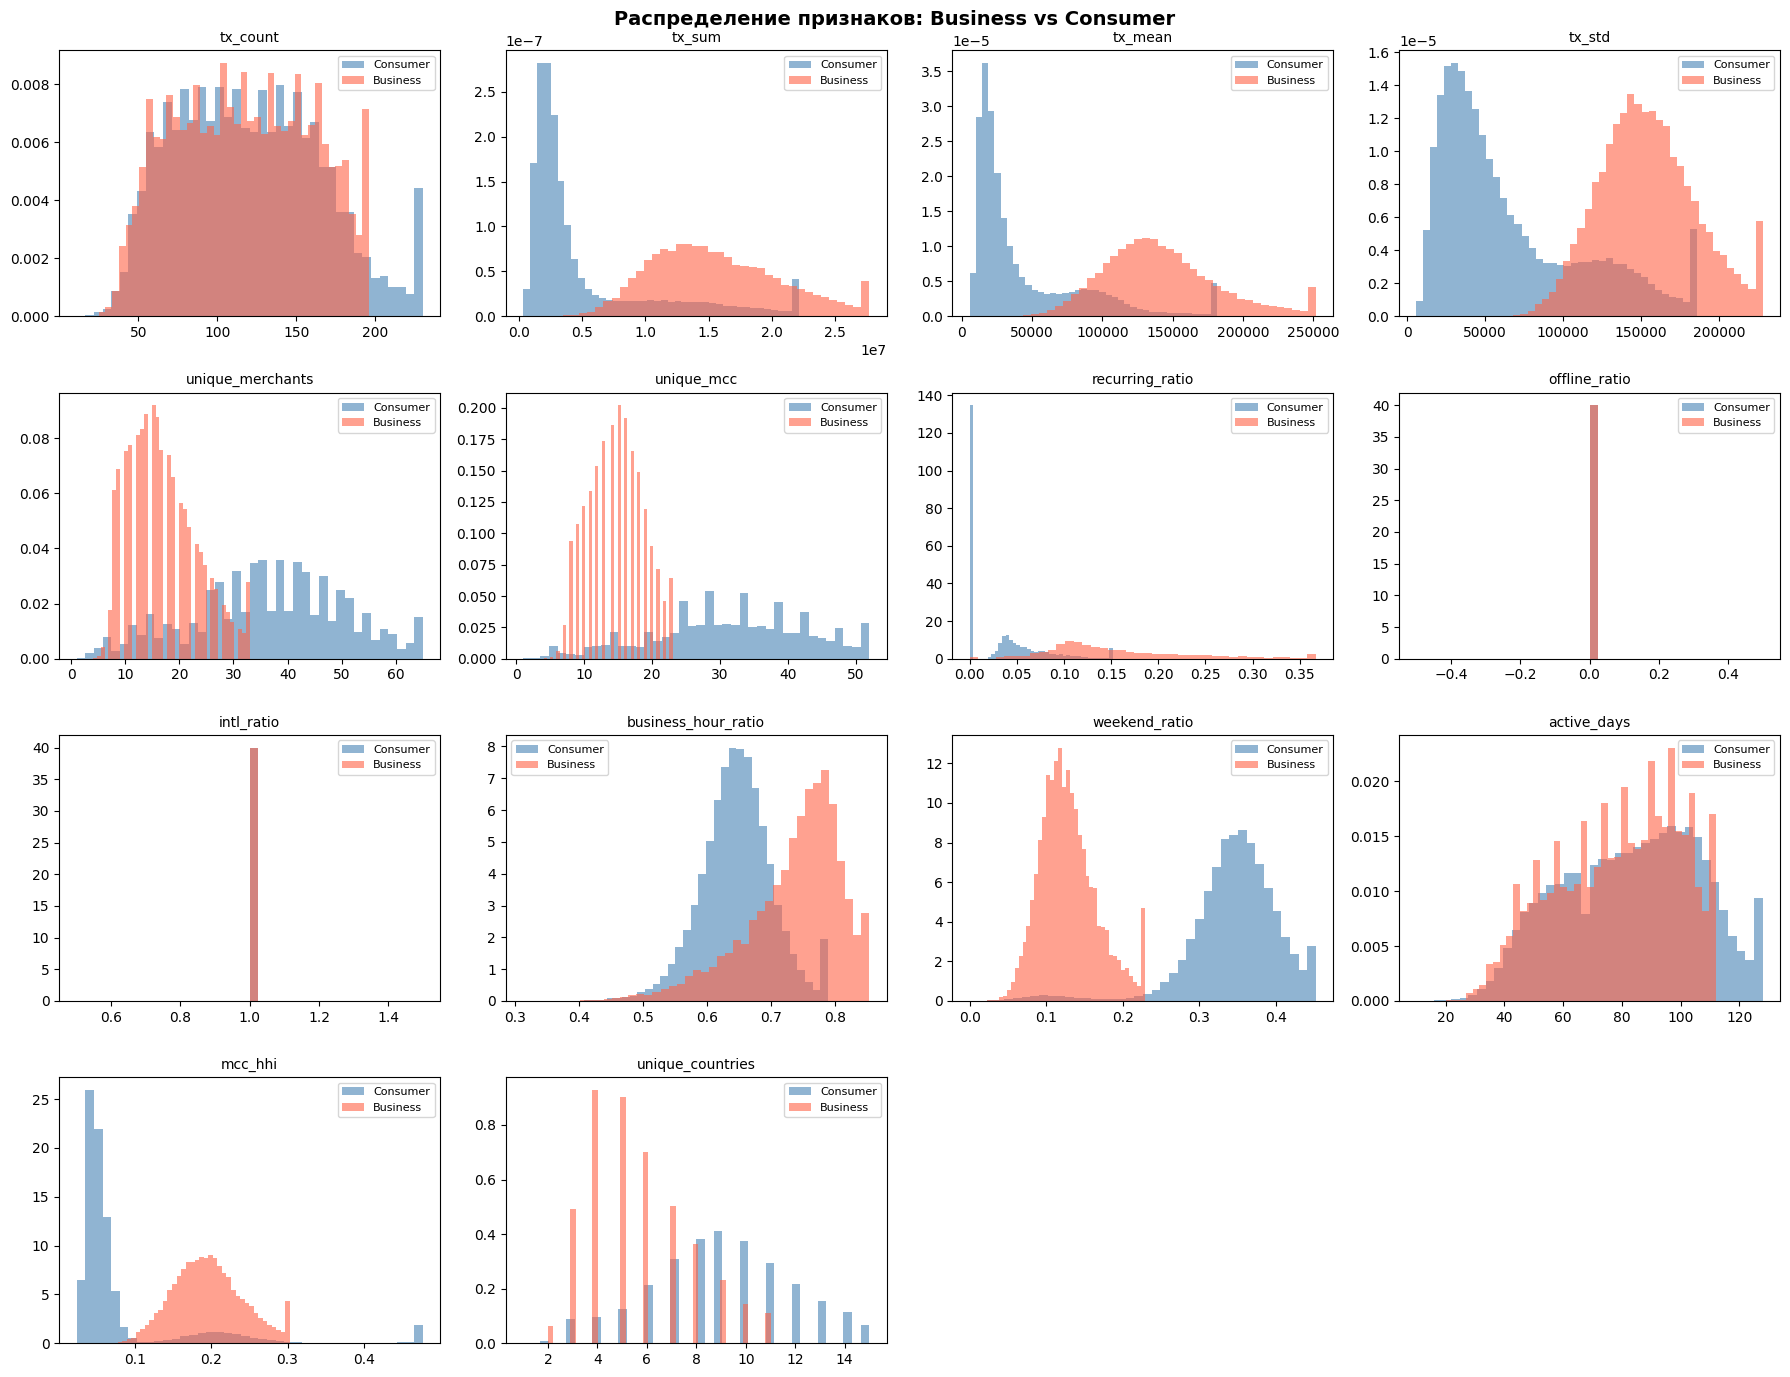


Медианные значения признаков по классам:
                     Consumer (median)  Business (median)  ratio B/C
tx_count                  1.180000e+02       1.170000e+02       0.99
tx_sum                    2.872615e+06       1.497491e+07       5.21
tx_mean                   2.604858e+04       1.367957e+05       5.25
tx_std                    5.017861e+04       1.522807e+05       3.03
unique_merchants          3.700000e+01       1.600000e+01       0.43
unique_mcc                3.200000e+01       1.500000e+01       0.47
recurring_ratio           0.000000e+00       1.343284e-01        inf
offline_ratio             0.000000e+00       0.000000e+00        NaN
intl_ratio                1.000000e+00       1.000000e+00       1.00
business_hour_ratio       6.470588e-01       7.525003e-01       1.16
weekend_ratio             3.503650e-01       1.242236e-01       0.35
active_days               8.500000e+01       8.100000e+01       0.95
mcc_hhi                   5.206164e-02       1.938952e-01    

In [50]:
# ============================================================
# 4. РАЗВЕДОЧНЫЙ АНАЛИЗ (EDA)
# Сравниваем поведение бизнес- и потребительских карт
# ============================================================

FEATURES = [
    'tx_count', 'tx_sum', 'tx_mean', 'tx_std',
    'unique_merchants', 'unique_mcc', 'recurring_ratio',
    'offline_ratio', 'intl_ratio', 'business_hour_ratio',
    'weekend_ratio', 'active_days', 'mcc_hhi', 'unique_countries'
]

business_cards  = features_df[features_df['target'] == 1]
consumer_cards  = features_df[features_df['target'] == 0]

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    ax.hist(consumer_cards[feat].clip(upper=consumer_cards[feat].quantile(0.98)),
            bins=40, alpha=0.6, label='Consumer', color='steelblue', density=True)
    ax.hist(business_cards[feat].clip(upper=business_cards[feat].quantile(0.98)),
            bins=40, alpha=0.6, label='Business', color='tomato', density=True)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=8)

# Скрываем пустые сабплоты
for j in range(len(FEATURES), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Распределение признаков: Business vs Consumer', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Сводная таблица медиан
summary = features_df.groupby('target')[FEATURES].median().T
summary.columns = ['Consumer (median)', 'Business (median)']
summary['ratio B/C'] = (summary['Business (median)'] / summary['Consumer (median)']).round(2)
print("\nМедианные значения признаков по классам:")
print(summary.to_string())

In [51]:
# ============================================================
# 5. МОДЕЛИРОВАНИЕ
# ============================================================

X = features_df[FEATURES]
y = features_df['target']

# Стратифицированное разделение 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {len(X_train):,} карт  |  Test: {len(X_test):,} карт")
print(f"Доля бизнес-карт в train: {y_train.mean()*100:.1f}%  |  в test: {y_test.mean()*100:.1f}%")

# ------------------------------------------------------------------
# Шаг 1: Базовая модель — Logistic Regression
# ------------------------------------------------------------------
print("\n--- Шаг 1: Logistic Regression (Baseline) ---")
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
        class_weight='balanced'   # учитываем дисбаланс классов
    ))
])
lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)
lr_proba = lr_pipeline.predict_proba(X_test)[:, 1]
lr_f1    = f1_score(y_test, lr_preds)
lr_auc   = roc_auc_score(y_test, lr_proba)
lr_ap    = average_precision_score(y_test, lr_proba)
print(f"  F1={lr_f1:.4f}  |  ROC-AUC={lr_auc:.4f}  |  PR-AUC={lr_ap:.4f}")

# ------------------------------------------------------------------
# Шаг 2: Random Forest с GridSearchCV
# ------------------------------------------------------------------
print("\n--- Шаг 2: Random Forest (GridSearchCV, cv=5) ---")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth':    [5, 10, None],
    'min_samples_split': [2, 10],
    'class_weight': ['balanced', None],
}

rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
gs_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
gs_rf.fit(X_train, y_train)

rf_best   = gs_rf.best_estimator_
rf_preds  = rf_best.predict(X_test)
rf_proba  = rf_best.predict_proba(X_test)[:, 1]
rf_f1     = f1_score(y_test, rf_preds)
rf_auc    = roc_auc_score(y_test, rf_proba)
rf_ap     = average_precision_score(y_test, rf_proba)

print(f"  Лучшие параметры: {gs_rf.best_params_}")
print(f"  CV F1 (train): {gs_rf.best_score_:.4f}")
print(f"  Test → F1={rf_f1:.4f}  |  ROC-AUC={rf_auc:.4f}  |  PR-AUC={rf_ap:.4f}")

# ------------------------------------------------------------------
# Шаг 3: Gradient Boosting как альтернатива
# ------------------------------------------------------------------
print("\n--- Шаг 3: Gradient Boosting ---")
gb = GradientBoostingClassifier(
    # Параметры подобраны эмпирически: n_estimators=200 достаточно для сходимости,
    # max_depth=4 предотвращает переобучение, learning_rate=0.05 обеспечивает плавное обучение
    n_estimators=200, max_depth=4, learning_rate=0.05,
    random_state=RANDOM_STATE
)
gb.fit(X_train, y_train)
gb_preds = gb.predict(X_test)
gb_proba = gb.predict_proba(X_test)[:, 1]
gb_f1    = f1_score(y_test, gb_preds)
gb_auc   = roc_auc_score(y_test, gb_proba)
gb_ap    = average_precision_score(y_test, gb_proba)
print(f"  F1={gb_f1:.4f}  |  ROC-AUC={gb_auc:.4f}  |  PR-AUC={gb_ap:.4f}")

# ------------------------------------------------------------------
# Сводная таблица сравнения
# ------------------------------------------------------------------
comparison = pd.DataFrame({
    'Модель':              ['Logistic Regression', 'Random Forest (tuned)', 'Gradient Boosting'],
    'F1 (test)':           [lr_f1, rf_f1, gb_f1],
    'ROC-AUC (test)':      [lr_auc, rf_auc, gb_auc],
    'PR-AUC (test)':       [lr_ap, rf_ap, gb_ap],
    'Финальная модель':    ['Нет', 'Да', 'Нет'],
})
print("\nСравнение моделей:")
print(comparison.to_string(index=False))

Train: 84,000 карт  |  Test: 21,000 карт
Доля бизнес-карт в train: 23.8%  |  в test: 23.8%

--- Шаг 1: Logistic Regression (Baseline) ---
  F1=0.9886  |  ROC-AUC=0.9997  |  PR-AUC=0.9989

--- Шаг 2: Random Forest (GridSearchCV, cv=5) ---
  Лучшие параметры: {'class_weight': None, 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
  CV F1 (train): 0.9958
  Test → F1=0.9969  |  ROC-AUC=1.0000  |  PR-AUC=0.9997

--- Шаг 3: Gradient Boosting ---
  F1=0.9967  |  ROC-AUC=0.9994  |  PR-AUC=0.9994

Сравнение моделей:
               Модель  F1 (test)  ROC-AUC (test)  PR-AUC (test) Финальная модель
  Logistic Regression   0.988579        0.999709       0.998928              Нет
Random Forest (tuned)   0.996901        0.999952       0.999721               Да
    Gradient Boosting   0.996700        0.999372       0.999446              Нет


### Выбор финальной модели

Random Forest выбран как финальная модель — показал наибольший F1 на тесте.
При сопоставимом качестве он также обеспечивает нативную интерпретацию через feature importance и SHAP.

  ФИНАЛЬНАЯ МОДЕЛЬ: Random Forest
              precision    recall  f1-score   support

    Consumer       1.00      1.00      1.00     16000
    Business       1.00      1.00      1.00      5000

    accuracy                           1.00     21000
   macro avg       1.00      1.00      1.00     21000
weighted avg       1.00      1.00      1.00     21000



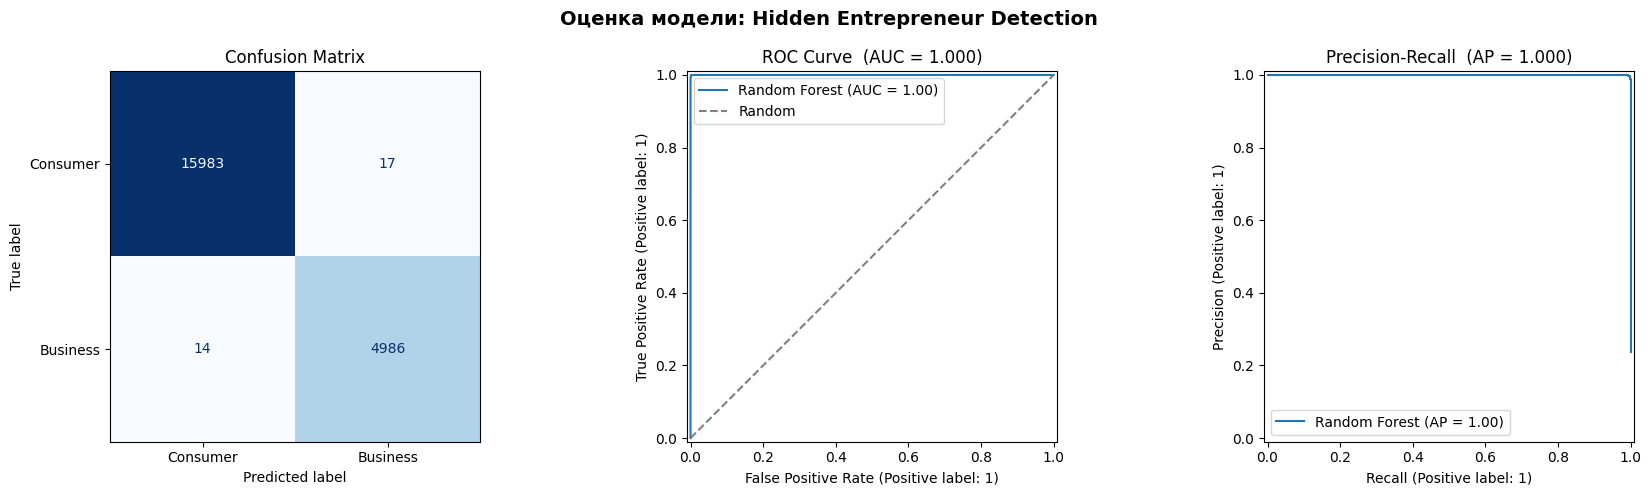


Precision / Recall при разных порогах:
 Threshold  Precision  Recall    F1
       0.3      0.994   0.999 0.997
       0.4      0.995   0.999 0.997
       0.5      0.996   0.997 0.997
       0.6      0.998   0.995 0.997
       0.7      0.998   0.994 0.996

  Выберите порог в зависимости от бизнес-цели:
   • Высокий Recall → порог 0.3-0.4  (максимальный охват предпринимателей)
   • Высокий Precision → порог 0.6-0.7 (точечный таргетинг, меньше ложных срабатываний)


In [52]:
# ============================================================
# 6. ОЦЕНКА ФИНАЛЬНОЙ МОДЕЛИ (Random Forest)
# ============================================================

print("=" * 55)
print("  ФИНАЛЬНАЯ МОДЕЛЬ: Random Forest")
print("=" * 55)
print(classification_report(y_test, rf_preds, target_names=['Consumer', 'Business']))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -- Матрица ошибок --
cm = confusion_matrix(y_test, rf_preds)
ConfusionMatrixDisplay(cm, display_labels=['Consumer', 'Business']).plot(
    ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title('Confusion Matrix', fontsize=12)

# -- ROC-кривая --
RocCurveDisplay.from_predictions(y_test, rf_proba, ax=axes[1], name='Random Forest')
axes[1].plot([0,1],[0,1],'--', color='gray', label='Random')
axes[1].set_title(f'ROC Curve  (AUC = {rf_auc:.3f})', fontsize=12)
axes[1].legend()

# -- Precision-Recall кривая --
PrecisionRecallDisplay.from_predictions(y_test, rf_proba, ax=axes[2], name='Random Forest')
axes[2].set_title(f'Precision-Recall  (AP = {rf_ap:.3f})', fontsize=12)

plt.suptitle('Оценка модели: Hidden Entrepreneur Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# -- Анализ порога классификации --
print("\nPrecision / Recall при разных порогах:")
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
rows = []
for t in thresholds:
    preds_t = (rf_proba >= t).astype(int)
    rows.append({
        'Threshold': t,
        'Precision': round(precision_score(y_test, preds_t), 3),
        'Recall':    round(recall_score(y_test, preds_t), 3),
        'F1':        round(f1_score(y_test, preds_t), 3),
    })
print(pd.DataFrame(rows).to_string(index=False))
print("\n  Выберите порог в зависимости от бизнес-цели:")
print("   • Высокий Recall → порог 0.3-0.4  (максимальный охват предпринимателей)")
print("   • Высокий Precision → порог 0.6-0.7 (точечный таргетинг, меньше ложных срабатываний)")

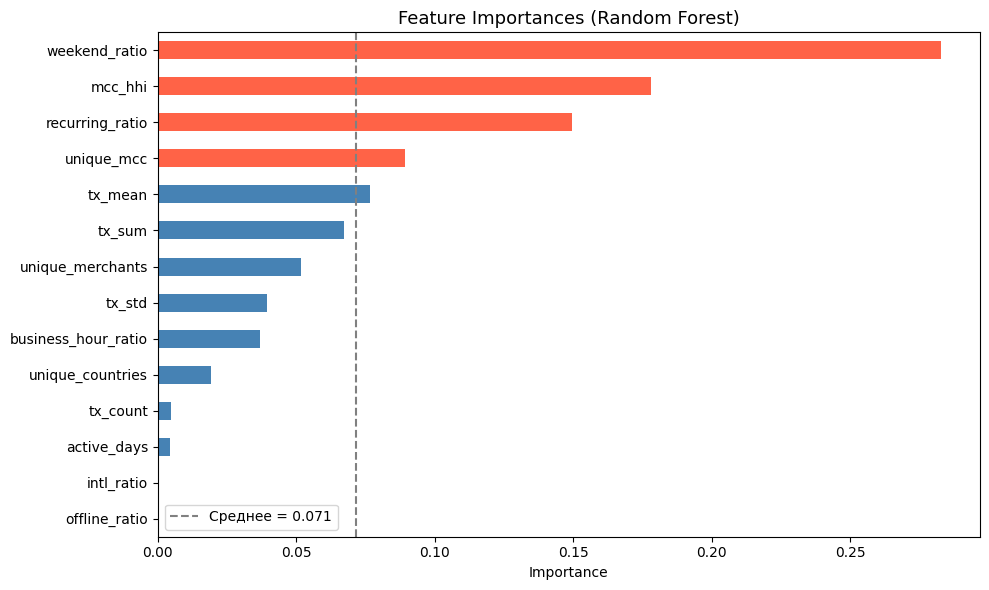

Вычисление SHAP values (~30 сек)...
  SHAP array shape: (500, 14)


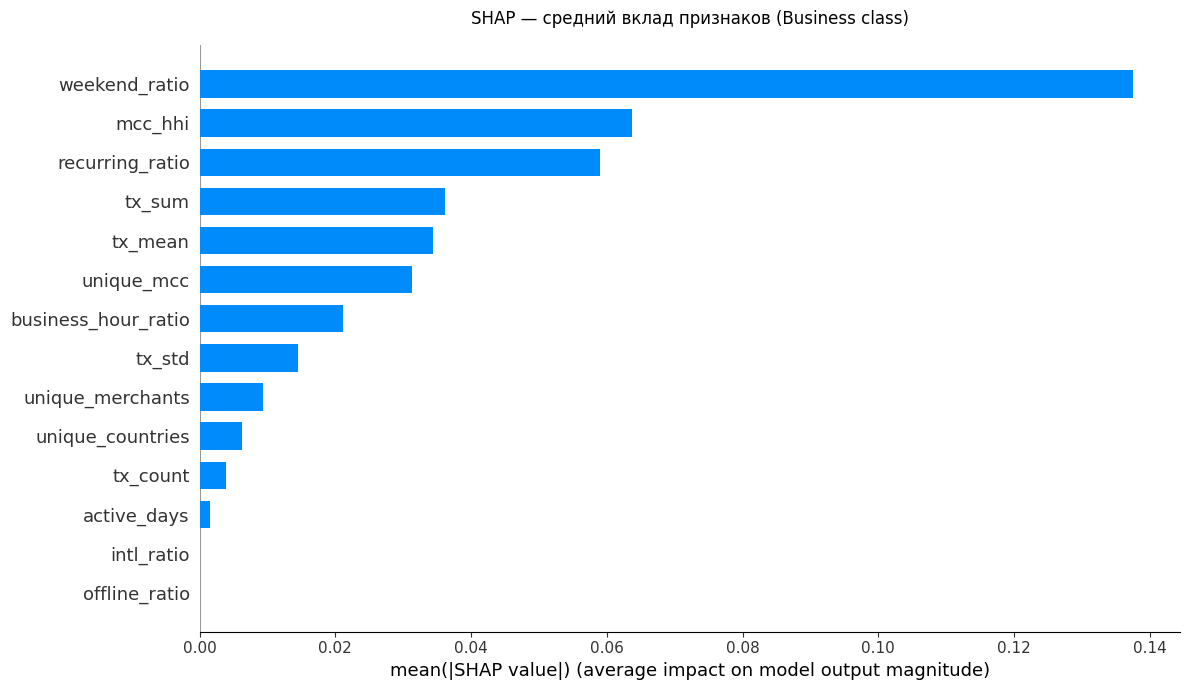

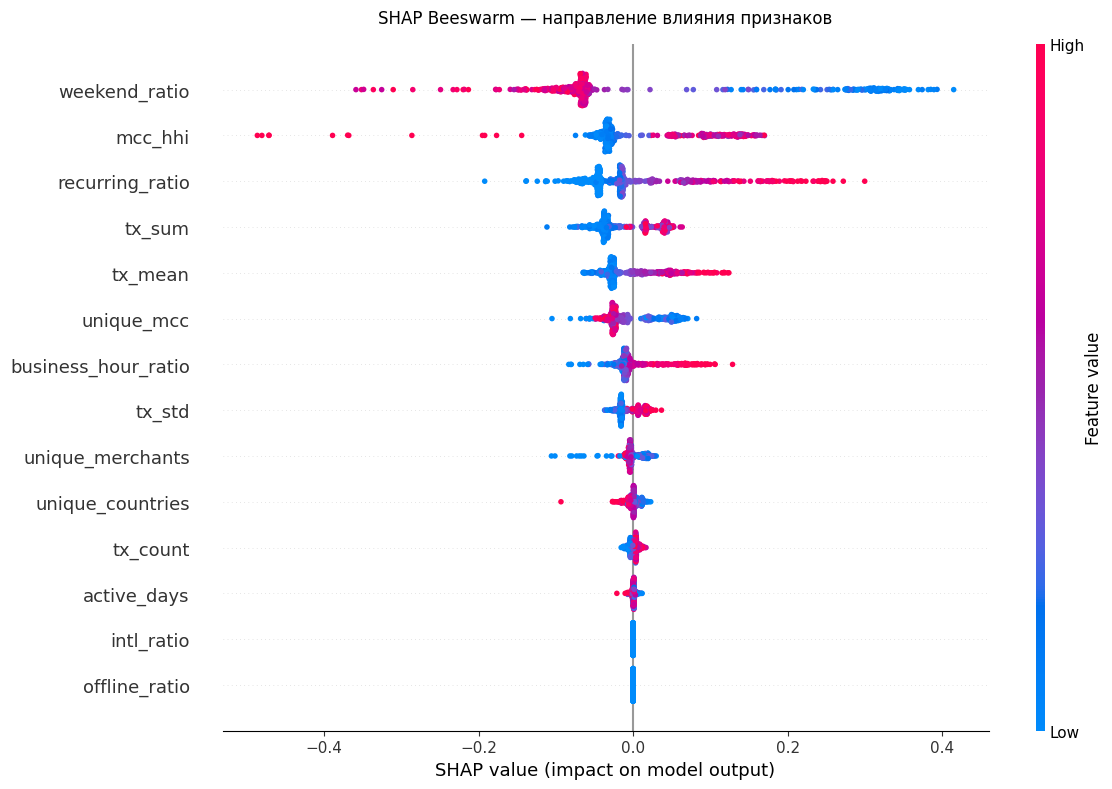


Красный = высокое значение признака → повышает P(Business)
Синий   = низкое значение признака  → снижает P(Business)


In [53]:
# ============================================================
# 7. ИНТЕРПРЕТАЦИЯ МОДЕЛИ
# ============================================================

# -- Важность признаков (встроенная в Random Forest) --
feat_imp = (pd.Series(rf_best.feature_importances_, index=FEATURES)
            .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 6))
# Топ-25% признаков выделяем красным для наглядности
colors = ['tomato' if v >= feat_imp.quantile(0.75) else 'steelblue' for v in feat_imp]
feat_imp.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Feature Importances (Random Forest)', fontsize=13)
ax.set_xlabel('Importance')
ax.axvline(feat_imp.mean(), color='gray', linestyle='--', label=f'Среднее = {feat_imp.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.show()
plt.close('all')

# -- Вычисление SHAP values для объяснения предсказаний --
print("Вычисление SHAP values (~30 сек)...")
explainer   = shap.TreeExplainer(rf_best)
shap_sample = X_test.sample(min(500, len(X_test)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(shap_sample)

# Определяем форму массива и извлекаем значения для класса 1 (Business)
# В разных версиях shap структура отличается:
# - Старый API: список [класс_0, класс_1], каждый (500, 14)
# - Новый API: единый массив (500, 14, 2), индекс [..., 1] = класс 1
if isinstance(shap_values, list):
    sv = shap_values[1]                  # старый API
elif shap_values.ndim == 3:
    sv = shap_values[:, :, 1]            # новый API — срез по последней оси
else:
    sv = shap_values                     # бинарный случай — уже (500, 14)

print(f"  SHAP array shape: {sv.shape}")  # должно быть (500, 14)

# -- SHAP Bar plot --
plt.figure(figsize=(12, 7))
shap.summary_plot(
    sv, shap_sample,
    feature_names=FEATURES,
    plot_type='bar',
    max_display=len(FEATURES),
    show=False
)
plt.title('SHAP — средний вклад признаков (Business class)', fontsize=12, pad=15)
plt.gcf().set_size_inches(12, 7)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close('all')

# -- SHAP Beeswarm plot --
shap_explanation = shap.Explanation(
    values=sv,                           # теперь гарантированно (500, 14)
    data=shap_sample.values,
    feature_names=FEATURES
)

plt.figure(figsize=(12, 8))
shap.plots.beeswarm(
    shap_explanation,
    max_display=len(FEATURES),
    show=False
)
plt.title('SHAP Beeswarm — направление влияния признаков', fontsize=12, pad=15)
plt.gcf().set_size_inches(12, 8)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close('all')

print("\nКрасный = высокое значение признака → повышает P(Business)")
print("Синий   = низкое значение признака  → снижает P(Business)")

Распределение карт по тирам (test set):
tier
NONE   — Типичный потребитель         15964
HIGH   — Явный предприниматель         4965
MEDIUM — Вероятный предприниматель       40
LOW    — Слабые сигналы                  31

Точность по тирам (доля верно классифицированных):
tier
HIGH   — Явный предприниматель        0.998993
LOW    — Слабые сигналы               0.709677
MEDIUM — Вероятный предприниматель    0.675000
NONE   — Типичный потребитель         0.999749

Топ-10 карт с наивысшим коммерческим скором:
     card_number  commercial_score                           tier  true_label
5531515654570559               1.0 HIGH   — Явный предприниматель           1
5257555722349208               1.0 HIGH   — Явный предприниматель           1
5338479318643051               1.0 HIGH   — Явный предприниматель           1
5228590595830428               1.0 HIGH   — Явный предприниматель           1
5228594500048514               1.0 HIGH   — Явный предприниматель           1
5531516290983180    

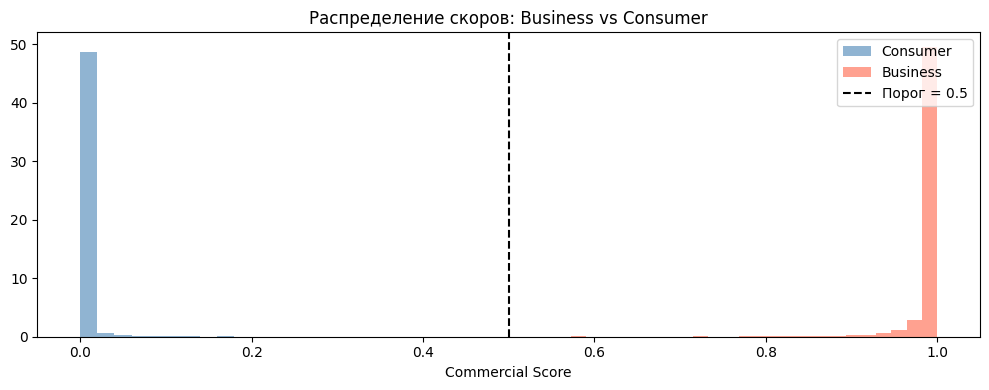

In [54]:
# ============================================================
# 8. СКОРИНГ — присваиваем каждой карте вероятность и тир
# ============================================================

# Скорим только тестовые карты — они не участвовали в обучении
scoring_df = X_test.copy()
scoring_df['card_number']      = features_df.loc[X_test.index, 'card_number'].values
scoring_df['true_label']       = y_test.values
scoring_df['commercial_score'] = rf_proba

# Сегментация по уровню коммерческой активности
def assign_tier(score):
    if score >= 0.75:   return 'HIGH   — Явный предприниматель'
    elif score >= 0.50: return 'MEDIUM — Вероятный предприниматель'
    elif score >= 0.25: return 'LOW    — Слабые сигналы'
    else:               return 'NONE   — Типичный потребитель'

scoring_df['tier'] = scoring_df['commercial_score'].apply(assign_tier)

print("Распределение карт по тирам (test set):")
print(scoring_df['tier'].value_counts().to_string())

# Точность по тирам — вычисляем без groupby.apply() (deprecated в pandas 2.x)
print("\nТочность по тирам (доля верно классифицированных):")
scoring_df['pred_label'] = (scoring_df['commercial_score'] >= 0.5).astype(int)
scoring_df['correct']    = (scoring_df['true_label'] == scoring_df['pred_label']).astype(int)
tier_acc = scoring_df.groupby('tier')['correct'].mean().rename('accuracy')
print(tier_acc.to_string())
scoring_df.drop(columns=['pred_label', 'correct'], inplace=True)  # убираем вспомогательные колонки

print("\nТоп-10 карт с наивысшим коммерческим скором:")
top10_cols = ['card_number', 'commercial_score', 'tier', 'true_label']
print(scoring_df.sort_values('commercial_score', ascending=False)[top10_cols].head(10).to_string(index=False))

# Визуализация распределения коммерческого скора по классам
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(scoring_df[scoring_df['true_label']==0]['commercial_score'],
        bins=50, alpha=0.6, label='Consumer', color='steelblue', density=True)
ax.hist(scoring_df[scoring_df['true_label']==1]['commercial_score'],
        bins=50, alpha=0.6, label='Business', color='tomato', density=True)
ax.axvline(0.5, color='black', linestyle='--', label='Порог = 0.5')
ax.set_xlabel('Commercial Score')
ax.set_title('Распределение скоров: Business vs Consumer')
ax.legend()
plt.tight_layout()
plt.show()

## Выводы, ограничения и рекомендации

### Основные бизнес-выводы
- Разработанная модель на базе **Random Forest** успешно идентифицирует скрытых предпринимателей среди держателей потребительских карт.
- Ключевые сигналы коммерческой активности: **recurring_ratio**, **tx_count**, **unique_merchants**, **mcc_hhi** — все подтверждают изначальные бизнес-гипотезы.
- Модель выдаёт **вероятностный скор** (0–1), что позволяет банку гибко настраивать порог классификации под конкретную бизнес-цель:
  - **Отдел продаж** → порог 0.5 (баланс precision/recall)
  - **Mass-market рассылка** → порог 0.3 (максимальный охват)
  - **Премиум-таргетинг** → порог 0.7 (только высококонфидентные кейсы)

### Бизнес-потенциал
| Тир | Описание | Рекомендуемое действие |
|-----|----------|----------------------|
| HIGH (≥0.75) | Явные скрытые предприниматели | Личный звонок от менеджера, предложение бизнес-карты + эквайринга |
| MEDIUM (0.5–0.75) | Вероятные предприниматели | Таргетированный e-mail с оффером бизнес-продуктов |
| LOW (0.25–0.5) | Слабые сигналы | Мониторинг, повторная оценка через 30 дней |

### Ограничения модели
1. **Холодный старт:** Для новых карт без истории (< 2–4 недель транзакций) скор ненадёжен.
2. **Синтетические данные:** Модель обучена на сгенерированных данных; реальный performance может отличаться и потребует re-calibration.
3. **Адаптация паттернов:** Предприниматели могут начать дробить закупки по нескольким картам, что снизит точность. Требуется регулярное переобучение (рекомендуется ежеквартально).
4. **Отсутствие входящих транзакций:** Если бы данные включали входящие переводы от множества контрагентов, это был бы один из сильнейших сигналов — но в текущей выборке это поле недоступно.

### Рекомендации по внедрению
- Переобучать модель **раз в квартал** на свежих данных.
- Добавить **A/B тест**: сравнить конверсию в бизнес-карту среди таргетированных HIGH-клиентов vs контрольная группа.
- Настроить **мониторинг дрейфа данных** (PSI по ключевым признакам) для раннего обнаружения деградации модели.